In [8]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_component_costs(filepath, component, top_limit):
    # Step 1: Load the CSV file
    df = pd.read_csv(filepath)
    
    # Step 2: Filter the rows excluding the "Total" row
    df_filtered = df[df['component costs'] != 'Total']

    # Step 3: Get the cost columns (excluding the 'component costs' column)
    cost_columns = df_filtered.columns[1:]  # Exclude the 'component costs' column
    
    # Step 4: Convert the data to millions of dollars
    df_filtered[cost_columns] = df_filtered[cost_columns] / 1000000  # Convert to millions

    # Step 5: Transpose the data for plotting
    # The 'component costs' values will become the legend, and the cost columns are the x-axis
    plot_data = df_filtered.set_index('component costs')[cost_columns].T

    # Define specific colors for each component type
    component_colors = {
        'Labor': 'deepskyblue',
        'Raw materials': 'mediumpurple',  # Soft purple
        'Factory amortization': '#FFA07A',  # Soft orange
        'Transportation': 'lightpink',  # Dark purple
        'Other': '#D3D3D3',  # Light grey for 'Other'
        'Tariffs': 'white',
    }

    # Step 6: Plot the stacked bar chart with black borders and custom colors
    ax = plot_data.plot(kind='bar', stacked=True, figsize=(9.5, 6.25), width=0.7, edgecolor='black', color=[component_colors.get(label, '#D3D3D3') for label in plot_data.columns], zorder=100)

    # Step 6.5: Add annotations for empty bars
    for idx, col in enumerate(plot_data.index):  # iterate over x-ticks (bars)
        bar_values = plot_data.loc[col]
        if bar_values.sum() == 0:
            ax.text(
                idx, 0.5 * top_limit,
                "The transportation via the Great Lakes\nis deemed impractical due to\nsize limitations of\nthe lock infrastructure.",
                ha='center', va='center', fontsize=8, color='black',
                bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.3'),
                zorder=200
            )

    # Step 7: Customize the plot
    plt.title(component + ' Cost Breakdowns (15-MW Turbine)', fontweight='bold')
    plt.ylabel('Landed Cost (Million $)', fontweight='bold')
    plt.xticks(rotation=0, fontweight='bold')  # Set x-axis labels rotation to 0 and make them bold
    plt.grid(True, axis='y', zorder=10)  # Add horizontal grid lines
    plt.legend(title='Cost Type')

    # Step 8: Annotate the bars with values, percentage, and $/kW
    printed_totals = set()  # Set to track which bars have already printed their total cost

    for i, rect in enumerate(ax.patches):
        # Get the height of the bar segment
        height = rect.get_height()
        
        # If the value is 0, skip the annotation
        if height == 0:
            continue
        
        # Get the x position (which cost type it belongs to)
        x_pos = rect.get_x() + rect.get_width() / 2

        # Calculate the total height of the bar (sum of all segments for that x position)
        total_height = sum([r.get_height() for r in ax.patches if r.get_x() == rect.get_x()])

        # Calculate the percentage of the total for that specific bar
        percentage = (height / total_height) * 100
        
        # Calculate the $/kW by dividing by 15000 kW
        cost_per_kw = (height * 1000000) / 15000  # Revert to dollars before dividing by 15000

        # Explicitly disable LaTeX rendering
        plt.rcParams['text.usetex'] = False

        # Use string formatting with just one dollar sign at the beginning, adding commas for thousands separation
        text = "\$" + "{:,.2f}M | {:.0f}% | ${:,.0f}/kW".format(height, percentage, cost_per_kw)

        # Position the text at the middle of the bar segment
        if(percentage>3.5):
            ax.text(x_pos, rect.get_y() + height / 2, text, ha='center', va='center', fontsize=9, color='black', zorder=200)

        # Step 9: Add total text on top of each stacked bar (without percentage), with commas for thousands separation
        if rect.get_x() not in printed_totals:
            total_cost = total_height
            total_cost_per_kw = (total_height * 1000000) / 15000
            total_text = "\$" + "{:,.2f}M | ${:,.0f}/kW".format(total_cost, total_cost_per_kw)
            ax.text(x_pos, total_height * 1.01, total_text, ha='center', va='bottom', fontsize=9, color='black', zorder=200)
            printed_totals.add(rect.get_x())

    # Step 10: Show the plot
    plt.ylim([0, top_limit])
    plt.tight_layout()
    plt.savefig("figures_final_results/" + component + filepath.replace(".", "").replace("/", "") + ".svg", format="svg", dpi=300)
    plt.show()


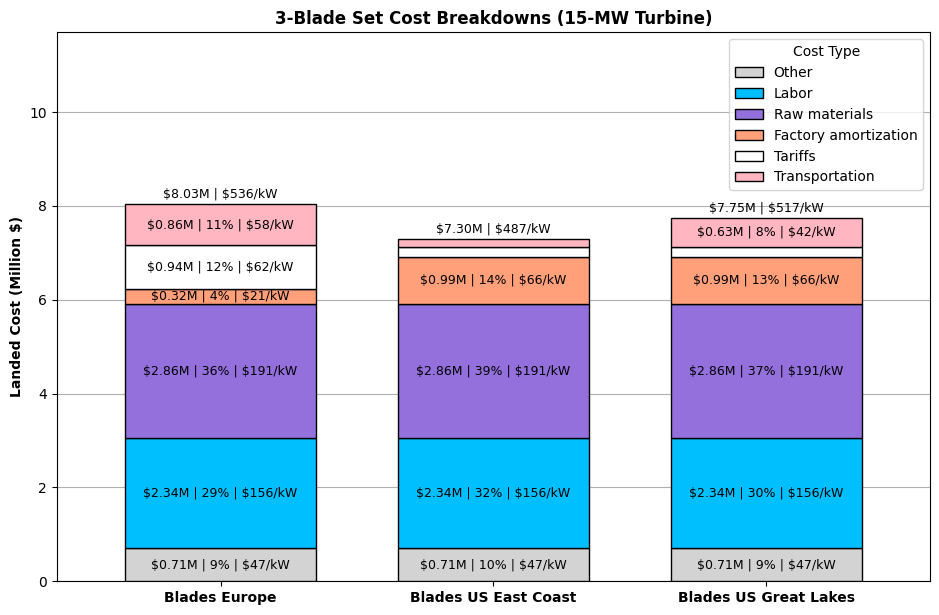

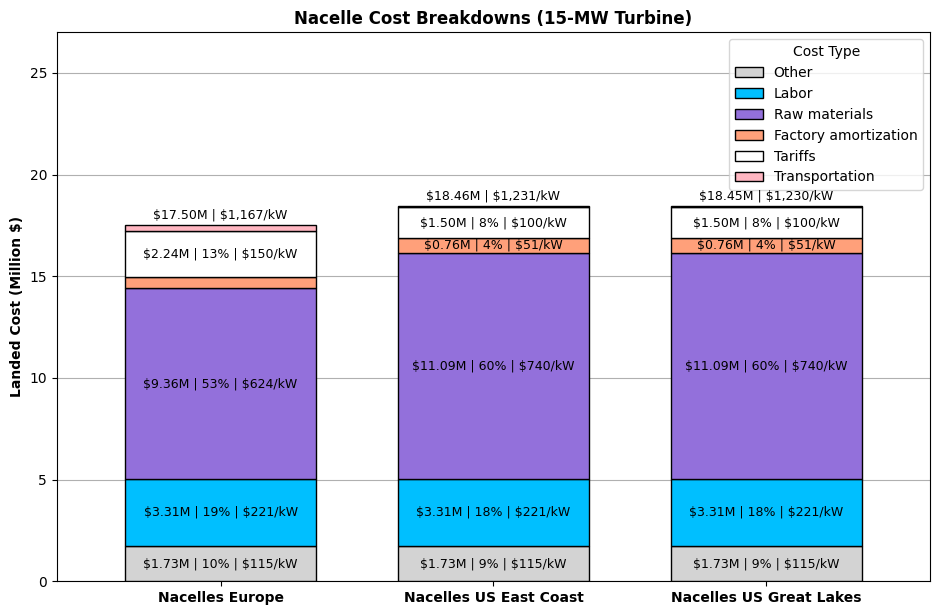

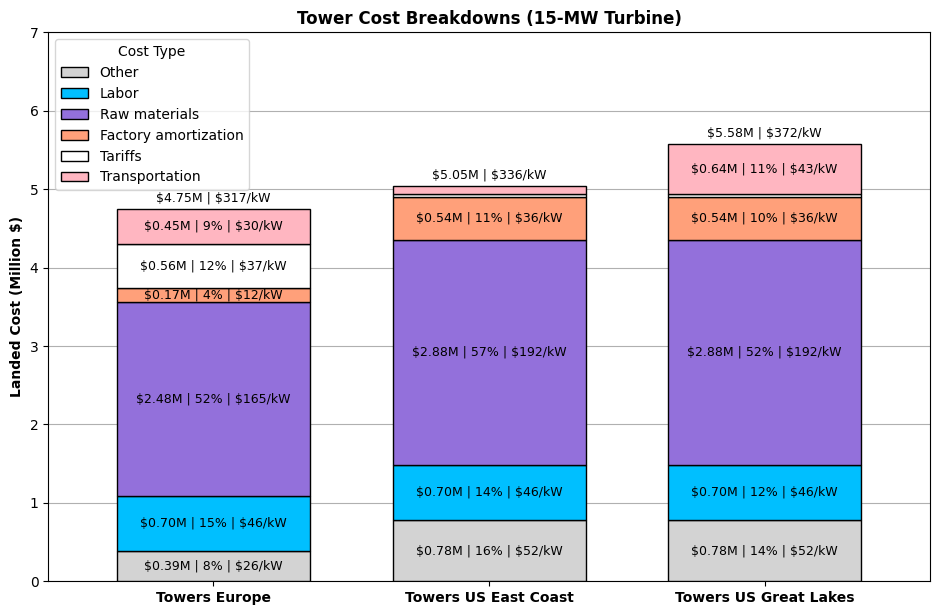

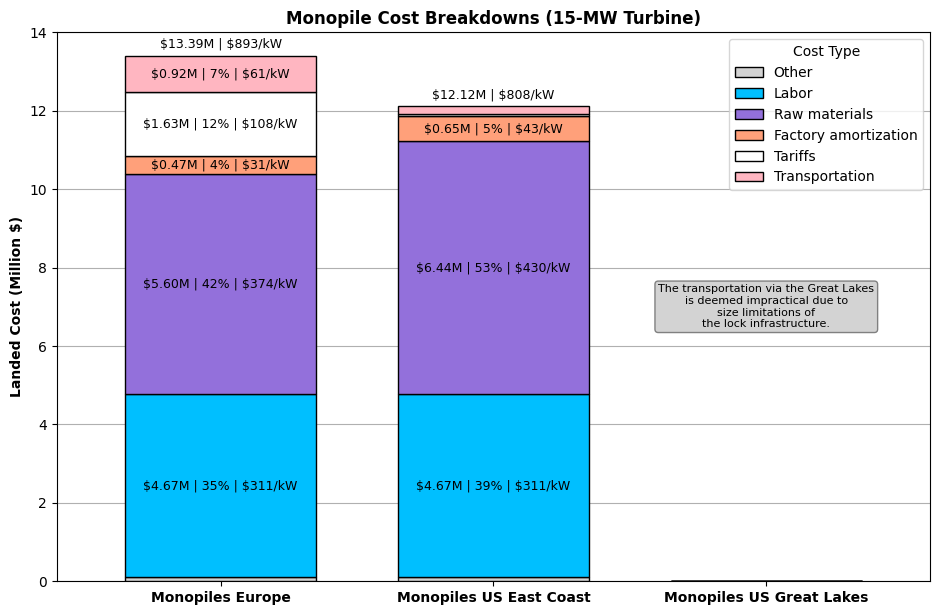

In [9]:
plot_component_costs('data_final_results/blades_final_results.csv', '3-Blade Set', 11.7)
plot_component_costs('data_final_results/nacelle_final_results.csv', 'Nacelle', 27)
plot_component_costs('data_final_results/tower_final_results.csv', 'Tower', 7)
plot_component_costs('data_final_results/monopile_final_results.csv', 'Monopile', 14)

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_component_costs(filepath, component, top_limit):
    # Step 1: Load the CSV file
    df = pd.read_csv(filepath)
    
    # Step 2: Filter the rows excluding the "Total" row
    df_filtered = df[df['component costs'] != 'Total']

    # Step 3: Get the cost columns (excluding the 'component costs' column)
    cost_columns = df_filtered.columns[1:]  # Exclude the 'component costs' column
    
    # Step 4: Convert the data to millions of dollars
    df_filtered[cost_columns] = df_filtered[cost_columns] / 1000000  # Convert to millions

    # Step 5: Transpose the data for plotting
    # The 'component costs' values will become the legend, and the cost columns are the x-axis
    plot_data = df_filtered.set_index('component costs')[cost_columns].T

    # Define specific colors for each component type
    component_colors = {
        'Labor': 'deepskyblue',
        'Raw materials': 'mediumpurple',  # Soft purple
        'Factory amortization': '#FFA07A',  # Soft orange
        'Transportation': 'lightpink',  # Dark purple
        'Other': '#D3D3D3',  # Light grey for 'Other'
        'Tariffs': 'white'
    }

    # Step 6: Plot the stacked bar chart with black borders and custom colors
    ax = plot_data.plot(kind='bar',stacked=True,figsize=(12, 7),edgecolor='black',width=0.8, color=[component_colors.get(label, '#D3D3D3') for label in plot_data.columns], zorder=100)

    # Step 6.5: Add annotations for empty bars
    for idx, col in enumerate(plot_data.index):  # iterate over x-ticks (bars)
        bar_values = plot_data.loc[col]
        if bar_values.sum() == 0:
            ax.text(
                idx, 0.5 * top_limit,
                "The transportation via the Great Lakes\nis deemed impractical due to\nsize limitations of\nthe lock infrastructure.",
                ha='center', va='center', fontsize=8, color='black',
                bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.3'),
                zorder=200
            )

    # Step 7: Customize the plot
    plt.title(component + ' Cost Breakdowns (15-MW Turbine)', fontweight='bold')
    plt.ylabel('Landed Cost (Million $)', fontweight='bold')
    plt.xticks(rotation=0, fontweight='bold')  # Set x-axis labels rotation to 0 and make them bold
    plt.grid(True, axis='y', zorder=10)  # Add horizontal grid lines
    plt.legend(title='Cost Type')

    # Step 8: Annotate the bars with values, percentage, and $/kW
    printed_totals = set()  # Set to track which bars have already printed their total cost

    for i, rect in enumerate(ax.patches):
        # Get the height of the bar segment
        height = rect.get_height()
        
        # If the value is 0, skip the annotation
        if height == 0:
            continue
        
        # Get the x position (which cost type it belongs to)
        x_pos = rect.get_x() + rect.get_width() / 2

        # Calculate the total height of the bar (sum of all segments for that x position)
        total_height = sum([r.get_height() for r in ax.patches if r.get_x() == rect.get_x()])

        # Calculate the percentage of the total for that specific bar
        percentage = (height / total_height) * 100
        
        # Calculate the $/kW by dividing by 15000 kW
        cost_per_kw = (height * 1000000) / 15000  # Revert to dollars before dividing by 15000

        # Explicitly disable LaTeX rendering
        plt.rcParams['text.usetex'] = False

        # Use string formatting with just one dollar sign at the beginning, adding commas for thousands separation
        text = "\$" + "{:,.2f}M | {:.0f}% | ${:,.0f}/kW".format(height, percentage, cost_per_kw)

        # Position the text at the middle of the bar segment
        if(percentage>3.5):
            ax.text(x_pos, rect.get_y() + height / 2, text, ha='center', va='center', fontsize=9, color='black', zorder=200)

        # Step 9: Add total text on top of each stacked bar (without percentage), with commas for thousands separation
        if rect.get_x() not in printed_totals:
            total_cost = total_height
            total_cost_per_kw = (total_height * 1000000) / 15000
            total_text = "\$" + "{:,.2f}M | ${:,.0f}/kW".format(total_cost, total_cost_per_kw)
            ax.text(x_pos, total_height * 1.01, total_text, ha='center', va='bottom', fontsize=9, color='black', zorder=200)
            printed_totals.add(rect.get_x())

    # Step 10: Show the plot
    plt.ylim([0, top_limit])
    plt.tight_layout()
    plt.savefig("figures_final_results/" + component + filepath.replace(".", "").replace("/", "") + ".svg", format="svg", dpi=300)
    plt.show()

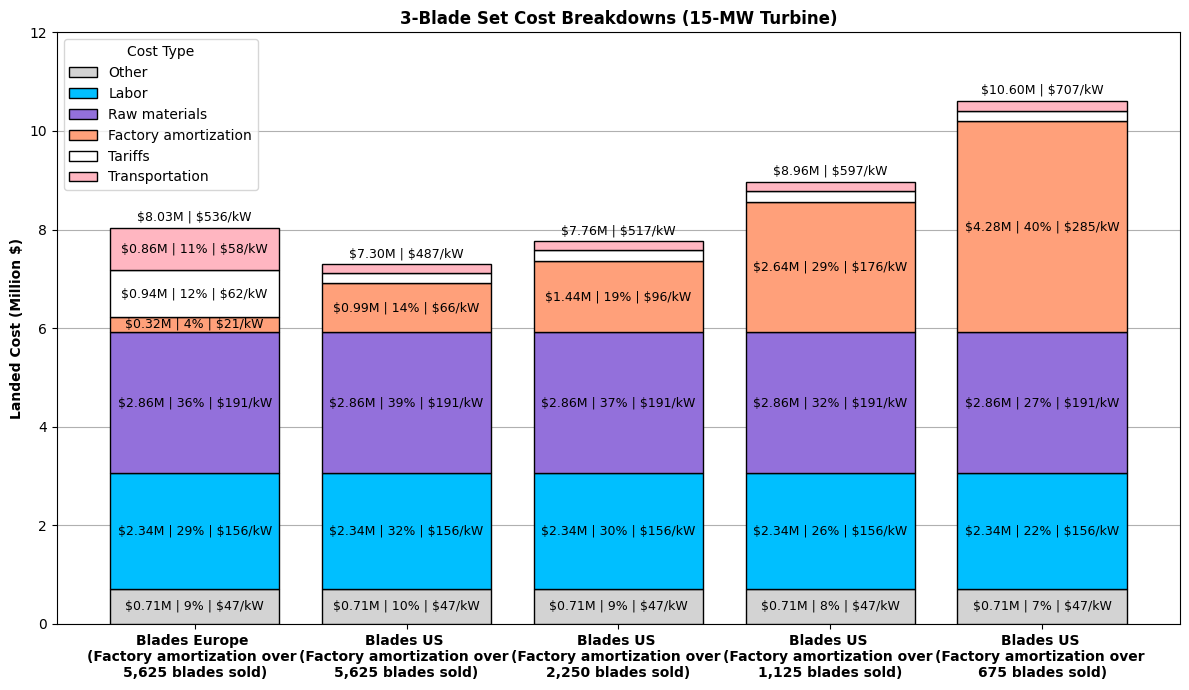

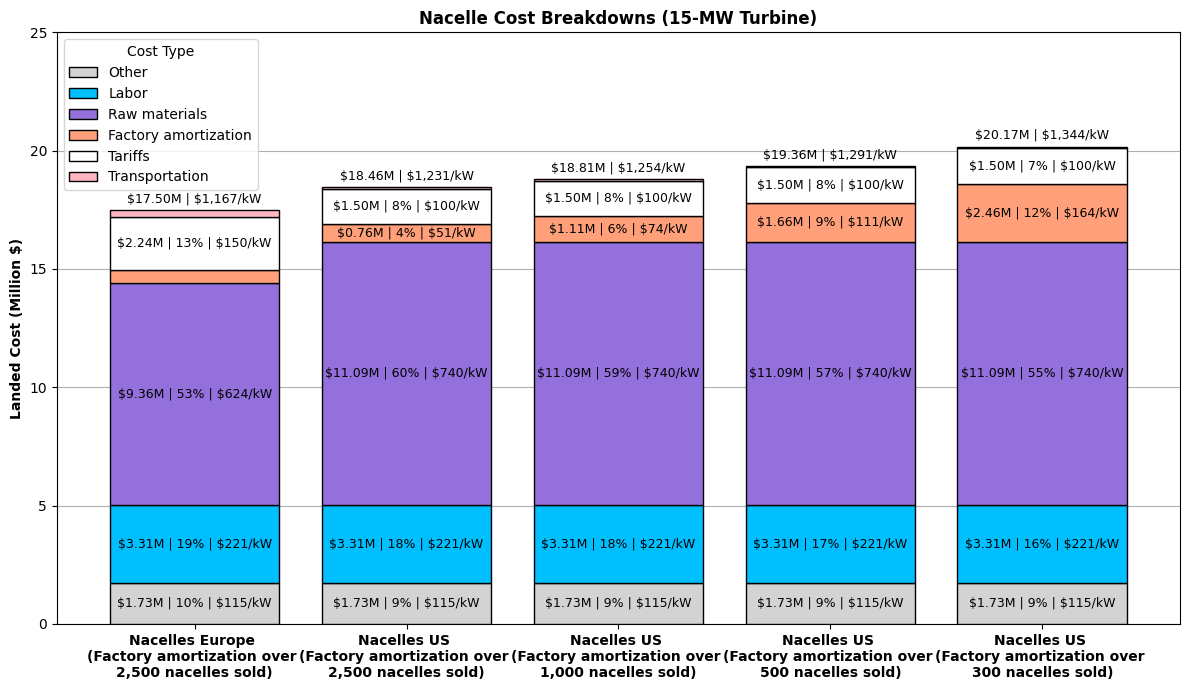

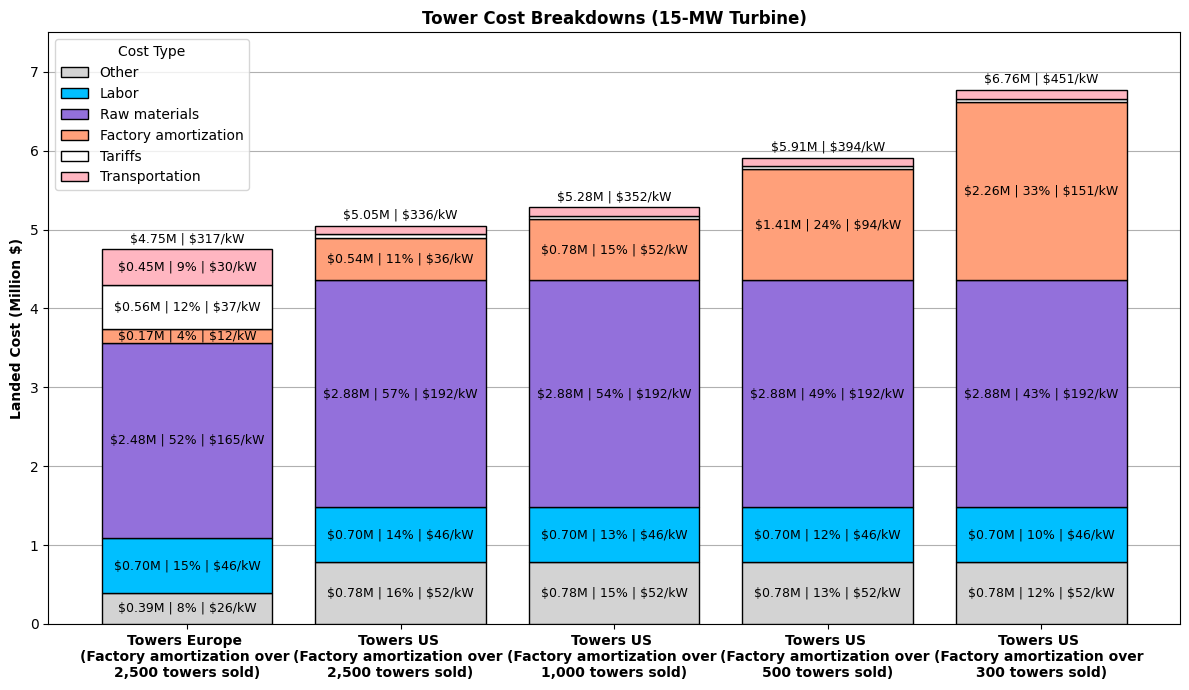

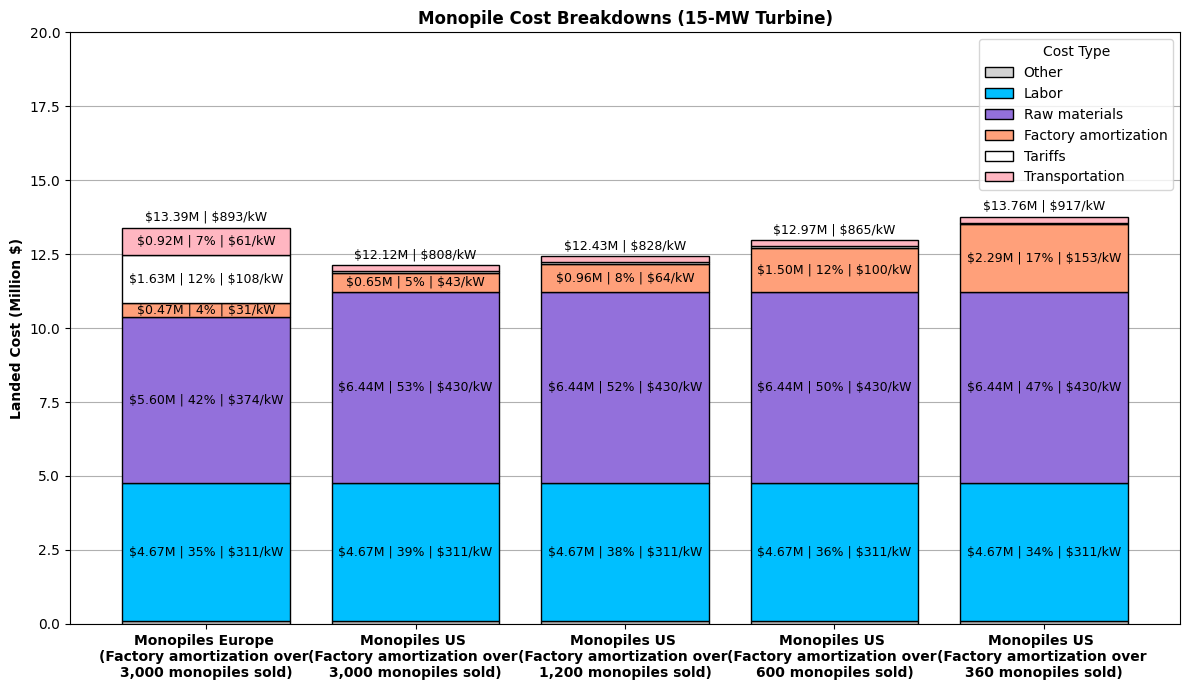

In [21]:
plot_component_costs('data_final_results/blades_sensitivities_final_results.csv', '3-Blade Set', 12)
plot_component_costs('data_final_results/nacelle_sensitivities_final_results.csv', 'Nacelle', 25)
plot_component_costs('data_final_results/tower_sensitivities_final_results.csv', 'Tower', 7.5)
plot_component_costs('data_final_results/monopile_sensitivities_final_results.csv', 'Monopile', 20)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_component_costs(filepath, component, top_limit):
    # Step 1: Load the CSV file
    df = pd.read_csv(filepath)
    
    # Step 2: Filter the rows excluding the "Total" row
    df_filtered = df[df['component costs'] != 'Total']

    # Step 3: Get the cost columns (excluding the 'component costs' column)
    cost_columns = df_filtered.columns[1:]  # Exclude the 'component costs' column
    
    # Step 4: Convert the data to millions of dollars
    df_filtered[cost_columns] = df_filtered[cost_columns] / 1000000  # Convert to millions

    # Step 5: Transpose the data for plotting
    # The 'component costs' values will become the legend, and the cost columns are the x-axis
    plot_data = df_filtered.set_index('component costs')[cost_columns].T

    # Define specific colors for each component type
    component_colors = {
        'Labor': 'deepskyblue',
        'Raw materials': 'mediumpurple',  # Soft purple
        'Factory amortization': '#FFA07A',  # Soft orange
        'Transportation': 'lightpink',  # Dark purple
        'Other': '#D3D3D3',  # Light grey for 'Other'
        'Tariffs': 'white'
    }

    # Step 6: Plot the stacked bar chart with black borders and custom colors
    ax = plot_data.plot(kind='bar', stacked=True, figsize=(9.5, 6.25), edgecolor='black', width=0.7, color=[component_colors.get(label, '#D3D3D3') for label in plot_data.columns], zorder=100)
    

    # Step 6.5: Add annotations for empty bars
    for idx, col in enumerate(plot_data.index):  # iterate over x-ticks (bars)
        bar_values = plot_data.loc[col]
        if bar_values.sum() == 0:
            ax.text(
                idx, 0.5 * top_limit,
                "The transportation via the Great Lakes\nis deemed impractical due to\nsize limitations of\nthe lock infrastructure.",
                ha='center', va='center', fontsize=8, color='black',
                bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.3'),
                zorder=200
            )
              

    # Step 7: Customize the plot
    plt.title(component + ' Cost Breakdowns (per km)', fontweight='bold')
    plt.ylabel('Cost (Million $)', fontweight='bold')
    plt.xticks(rotation=0, fontweight='bold')  # Set x-axis labels rotation to 0 and make them bold
    plt.grid(True, axis='y', zorder=10)  # Add horizontal grid lines
    
    # Reverse the order of legend items
    plt.legend(title='Cost Type')
    
    # Step 8: Annotate the bars with values, percentage, and $/kW
    printed_totals = set()  # Set to track which bars have already printed their total cost
    
    for i, rect in enumerate(ax.patches):
        # Get the height of the bar segment
        height = rect.get_height()
        
        # If the value is 0, skip the annotation
        if height == 0:
            continue
        
        # Get the x position (which cost type it belongs to)
        x_pos = rect.get_x() + rect.get_width() / 2

        # Calculate the total height of the bar (sum of all segments for that x position)
        total_height = sum([r.get_height() for r in ax.patches if r.get_x() == rect.get_x()])

        # Calculate the percentage of the total for that specific bar
        percentage = (height / total_height) * 100
        
        # Calculate the $/kW by dividing by 15000 kW
        cost_per_km = height  # Revert to dollars before dividing by 15000
        
        # Explicitly disable LaTeX rendering
        plt.rcParams['text.usetex'] = False

        # Use string formatting with just one dollar sign at the beginning, adding commas for thousands separation
        text = "{:.0f}% | ${:,.2f}M/km".format(percentage, cost_per_km)
        
        # Position the text at the middle of the bar segment
        if(percentage>1.5):
            ax.text(x_pos, rect.get_y() + height / 2, text, ha='center', va='center', fontsize=9, color='black', zorder=200)

        # Step 9: Add total text on top of each stacked bar (without percentage), with commas for thousands separation
        # Only print the total cost for each bar once
        if rect.get_x() not in printed_totals:  # If this bar hasn't had its total printed yet
            total_cost = total_height  # Total cost in millions
            total_cost_per_km = total_height  # $/kW for the total of the bar

            # Format the total text: "$1.99M | $133/kW", with commas for thousands
            total_text = "\${:,.2f}M/km".format(total_cost_per_km)

            # Place the total text at the top of each bar (above the highest segment)
            ax.text(x_pos, total_height * 1.01, total_text, ha='center', va='bottom', fontsize=9, color='black', zorder=200)

            # Add this x position to the set so we know this bar has had its total printed
            printed_totals.add(rect.get_x())

    # Step 10: Show the plot
    plt.ylim([0,top_limit])
    plt.tight_layout()
    plt.savefig("figures_final_results/"+ component + filepath.replace(".", "").replace("/", "") + ".svg", format="svg", dpi=300)
    plt.show()


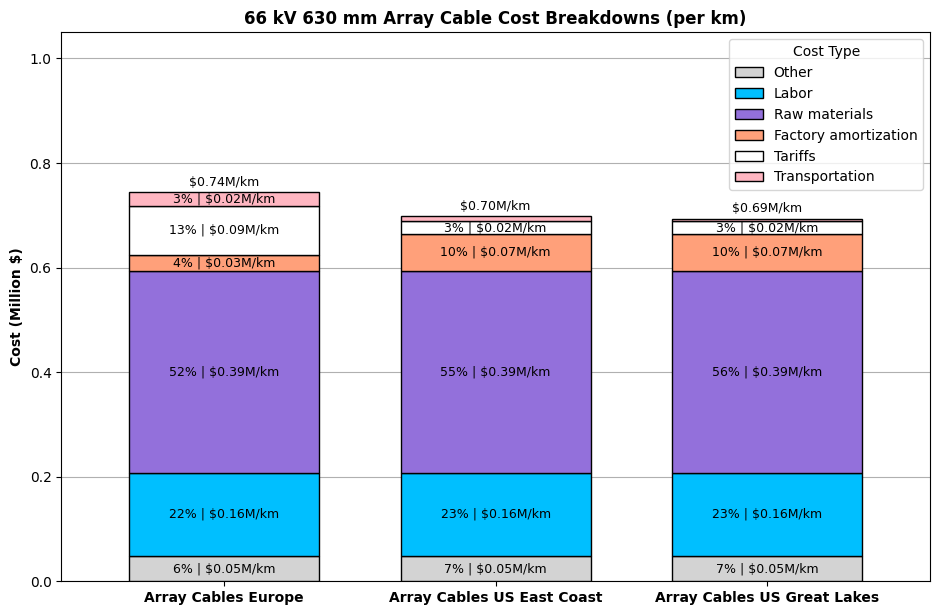

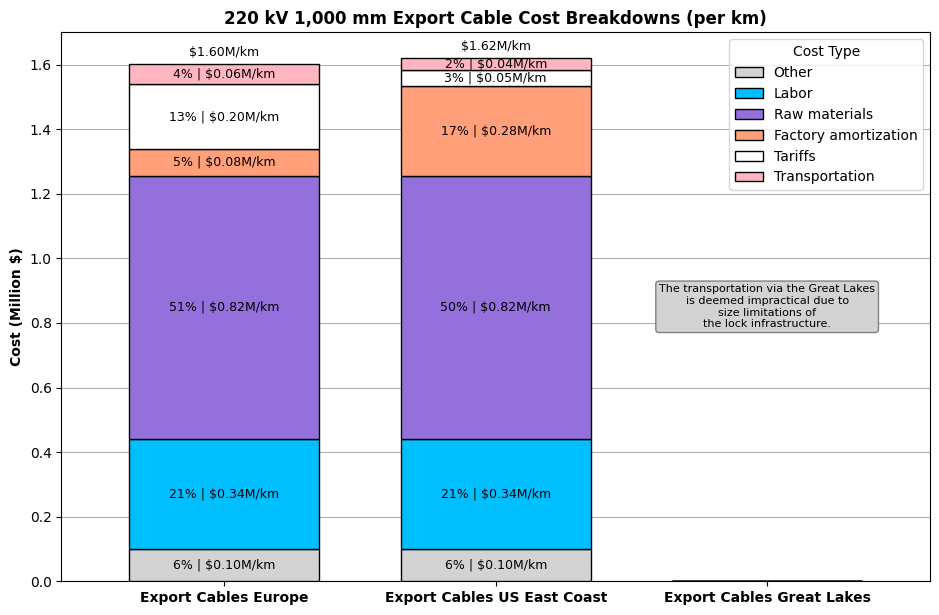

In [15]:
plot_component_costs('data_final_results/array_cable_final_results.csv', '66 kV 630 mm Array Cable', 1.05)
plot_component_costs('data_final_results/export_cable_final_results.csv', '220 kV 1,000 mm Export Cable', 1.7)

In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_component_costs(filepath, component, top_limit):
    # Step 1: Load the CSV file
    df = pd.read_csv(filepath)
    
    # Step 2: Filter the rows excluding the "Total" row
    df_filtered = df[df['component costs'] != 'Total']

    # Step 3: Get the cost columns (excluding the 'component costs' column)
    cost_columns = df_filtered.columns[1:]  # Exclude the 'component costs' column
    
    # Step 4: Convert the data to millions of dollars
    df_filtered[cost_columns] = df_filtered[cost_columns] / 1000000  # Convert to millions

    # Step 5: Transpose the data for plotting
    # The 'component costs' values will become the legend, and the cost columns are the x-axis
    plot_data = df_filtered.set_index('component costs')[cost_columns].T

    # Define specific colors for each component type
    component_colors = {
        'Labor': 'deepskyblue',
        'Raw materials': 'mediumpurple',  # Soft purple
        'Factory amortization': '#FFA07A',  # Soft orange
        'Transportation': 'lightpink',  # Dark purple
        'Other': '#D3D3D3',  # Light grey for 'Other'
        'Tariffs': 'white'
    }

    # Step 6: Plot the stacked bar chart with black borders and custom colors
    ax = plot_data.plot(kind='bar',stacked=True,figsize=(14, 7),edgecolor='black',width=0.8, color=[component_colors.get(label, '#D3D3D3') for label in plot_data.columns], zorder=100)
    

    # Step 6.5: Add annotations for empty bars
    for idx, col in enumerate(plot_data.index):  # iterate over x-ticks (bars)
        bar_values = plot_data.loc[col]
        if bar_values.sum() == 0:
            ax.text(
                idx, 0.5 * top_limit,
                "The transportation via the Great Lakes\nis deemed impractical due to\nsize limitations of\nthe lock infrastructure.",
                ha='center', va='center', fontsize=8, color='black',
                bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.3'),
                zorder=200
            )
              

    # Step 7: Customize the plot
    plt.title(component + ' Cost Breakdowns (per km)', fontweight='bold')
    plt.ylabel('Cost (Million $)', fontweight='bold')
    plt.xticks(rotation=0, fontweight='bold')  # Set x-axis labels rotation to 0 and make them bold
    plt.grid(True, axis='y', zorder=10)  # Add horizontal grid lines
    
    # Reverse the order of legend items
    plt.legend(title='Cost Type')
    
    # Step 8: Annotate the bars with values, percentage, and $/kW
    printed_totals = set()  # Set to track which bars have already printed their total cost
    
    for i, rect in enumerate(ax.patches):
        # Get the height of the bar segment
        height = rect.get_height()
        
        # If the value is 0, skip the annotation
        if height == 0:
            continue
        
        # Get the x position (which cost type it belongs to)
        x_pos = rect.get_x() + rect.get_width() / 2

        # Calculate the total height of the bar (sum of all segments for that x position)
        total_height = sum([r.get_height() for r in ax.patches if r.get_x() == rect.get_x()])

        # Calculate the percentage of the total for that specific bar
        percentage = (height / total_height) * 100
        
        # Calculate the $/kW by dividing by 15000 kW
        cost_per_km = height  # Revert to dollars before dividing by 15000
        
        # Explicitly disable LaTeX rendering
        plt.rcParams['text.usetex'] = False

        # Use string formatting with just one dollar sign at the beginning, adding commas for thousands separation
        text = "{:.0f}% | ${:,.2f}M/km".format(percentage, cost_per_km)
        
        # Position the text at the middle of the bar segment
        if(percentage>3.5):
            ax.text(x_pos, rect.get_y() + height / 2, text, ha='center', va='center', fontsize=10, color='black', zorder=200)

        # Step 9: Add total text on top of each stacked bar (without percentage), with commas for thousands separation
        # Only print the total cost for each bar once
        if rect.get_x() not in printed_totals:  # If this bar hasn't had its total printed yet
            total_cost = total_height  # Total cost in millions
            total_cost_per_km = total_height  # $/kW for the total of the bar

            # Format the total text: "$1.99M | $133/kW", with commas for thousands
            total_text = "\${:,.2f}M/km".format(total_cost_per_km)

            # Place the total text at the top of each bar (above the highest segment)
            ax.text(x_pos, total_height * 1.01, total_text, ha='center', va='bottom', fontsize=10, color='black', zorder=200)

            # Add this x position to the set so we know this bar has had its total printed
            printed_totals.add(rect.get_x())

    # Step 10: Show the plot
    plt.ylim([0,top_limit])
    plt.tight_layout()
    plt.savefig("figures_final_results/"+ component + filepath.replace(".", "").replace("/", "") + ".svg", format="svg", dpi=300)
    plt.show()

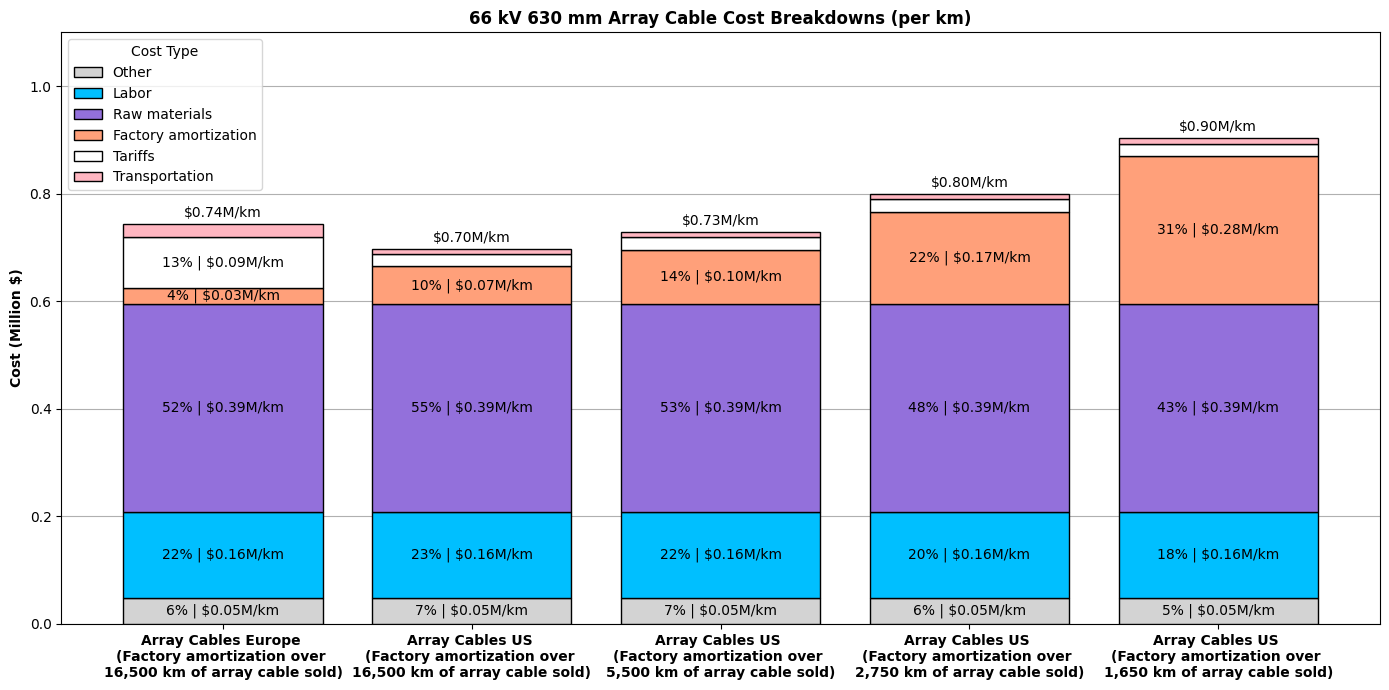

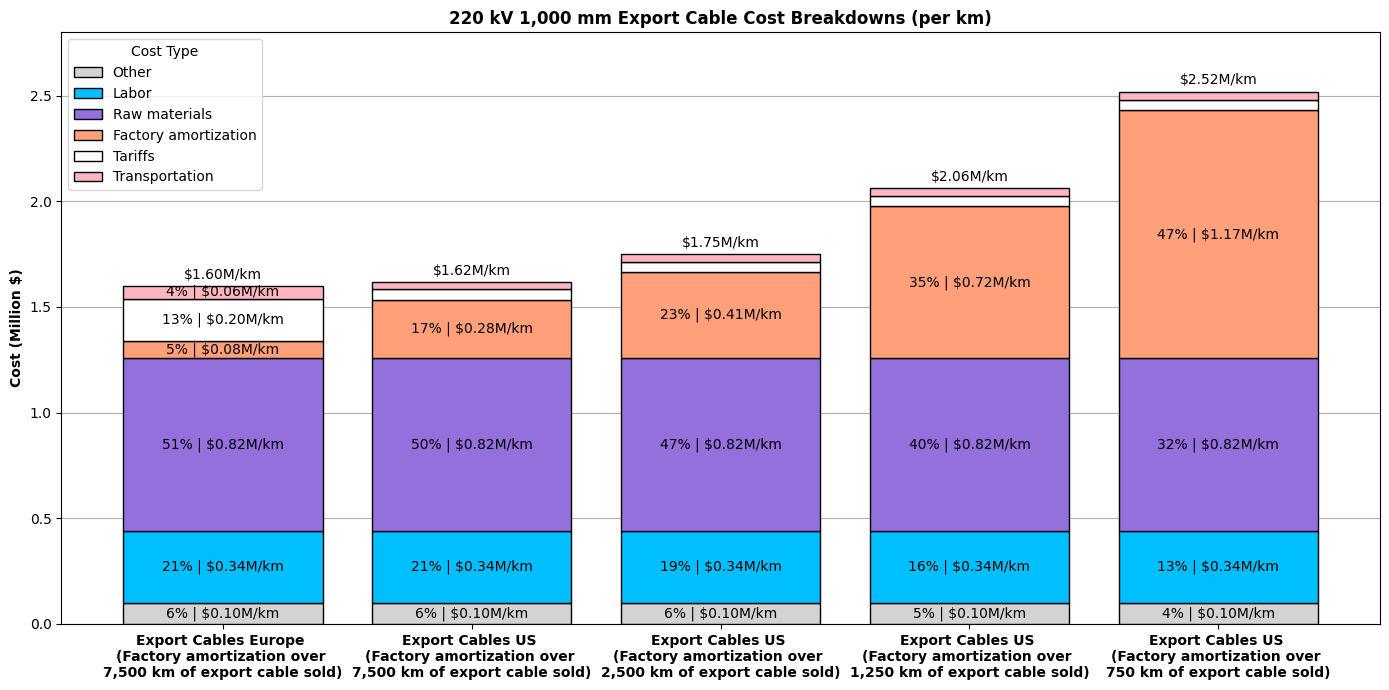

In [25]:
plot_component_costs('data_final_results/array_cable_sensitivities_final_results.csv', '66 kV 630 mm Array Cable', 1.1)
plot_component_costs('data_final_results/export_cable_sensitivities_final_results.csv', '220 kV 1,000 mm Export Cable', 2.8)